# Train 2 Metrics Dashboard

Visualize artifacts produced by `poc/train_2.py`.

This notebook assumes task-aware score decoding used in training:

- `latR` and `latL` anchors: `[0, 25, 50, 100]`
- `elev` anchors: `[0, 50, 100]`

Predicted scores are continuous values derived from model outputs and these anchors.

In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'poc' else Path.cwd()
TRAIN2_DIR = ROOT / 'poc' / 'out' / 'train2'

# Pin to the run you want to inspect.
# Note: your message used run_20260420_1143000; if that exact folder doesn't exist,
# the code suggests close matches.
RUN_NAME = 'run_20260420_114300_k5_s4'
RUN_DIR = TRAIN2_DIR / RUN_NAME
if not RUN_DIR.exists():
    candidates = sorted([p.name for p in TRAIN2_DIR.glob('run_20260420_114300*') if p.is_dir()])
    raise RuntimeError(
        f'Run not found: {RUN_DIR}\n'
        f'Close matches: {candidates if candidates else "none"}'
    )
print('Using run:', RUN_DIR)

SEED_DIRS = sorted([p for p in RUN_DIR.glob('seed_*') if p.is_dir()], key=lambda p: p.name)
if not SEED_DIRS:
    raise RuntimeError(f'No seed_* directories found under {RUN_DIR}')
print('Found seeds:', [p.name for p in SEED_DIRS])

TASK_MAP = {0: 'latR', 1: 'latL', 2: 'elev'}
TASK_ANCHORS = {
    'latR': [0, 25, 50, 100],
    'latL': [0, 25, 50, 100],
    'elev': [0, 50, 100],
}
print('Task anchors:', TASK_ANCHORS)


Using run: /home/srl/orosense_lateralization/poc/out/train2/run_20260420_114300_k5_s4
Found seeds: ['seed_139', 'seed_236', 'seed_333', 'seed_42']
Task anchors: {'latR': [0, 25, 50, 100], 'latL': [0, 25, 50, 100], 'elev': [0, 50, 100]}


In [10]:
# Load summaries, histories, and validation predictions from all seeds/folds/models
rows = []
history_rows = []
pred_rows = []

for seed_dir in SEED_DIRS:
    fold_dirs = sorted([d for d in seed_dir.glob('fold_*') if d.is_dir()], key=lambda p: p.name)
    for fold_dir in fold_dirs:
        model_dirs = [d for d in fold_dir.iterdir() if d.is_dir()]
        for model_dir in model_dirs:
            model_name = model_dir.name

            s = model_dir / 'summary.json'
            if s.exists():
                rec = json.loads(s.read_text())
                rec['seed'] = seed_dir.name
                rec['fold'] = fold_dir.name
                rec['model'] = model_name
                rows.append(rec)

            h = model_dir / 'history.csv'
            if h.exists():
                hdf = pd.read_csv(h)
                if not hdf.empty:
                    hdf['seed'] = seed_dir.name
                    hdf['fold'] = fold_dir.name
                    hdf['model'] = model_name
                    history_rows.append(hdf)

            vp = model_dir / 'val_predictions.csv'
            if vp.exists():
                pdf = pd.read_csv(vp)
                if not pdf.empty:
                    pdf['seed'] = seed_dir.name
                    pdf['fold'] = fold_dir.name
                    pdf['model'] = model_name
                    pred_rows.append(pdf)

summary_df = pd.DataFrame(rows)
hist_df = pd.concat(history_rows, ignore_index=True) if history_rows else pd.DataFrame()
all_preds_raw = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()
if all_preds_raw.empty:
    raise RuntimeError('No val_predictions.csv found under seed_*/fold_* directories')

# Prefer averaged predictions across seeds if available
avg_path = RUN_DIR / 'avg_predictions_across_seeds.csv'
if avg_path.exists():
    all_preds = pd.read_csv(avg_path)
    if 'model' not in all_preds.columns and 'model_name' in all_preds.columns:
        all_preds['model'] = all_preds['model_name']
    if 'pred_score' not in all_preds.columns and 'pred_score_mean' in all_preds.columns:
        all_preds['pred_score'] = all_preds['pred_score_mean']
    all_preds['fold'] = all_preds['fold'].apply(lambda x: f'fold_{int(x)}')
    print('Using averaged predictions file:', avg_path)
else:
    all_preds = all_preds_raw.copy()
    print('avg_predictions_across_seeds.csv not found; using raw predictions from each seed.')

required_cols = ['model', 'fold', 'task_id', 'true_score', 'pred_score']
missing = [c for c in required_cols if c not in all_preds.columns]
if missing:
    raise RuntimeError(f'Missing required prediction columns: {missing}')

all_preds['task'] = all_preds['task_id'].map(TASK_MAP)

# Round continuous prediction to nearest valid task bin
def nearest_bin_id(pred_score, anchors):
    arr = np.asarray(anchors, dtype=float)
    return int(np.argmin(np.abs(arr - float(pred_score))))

def gt_bin_id(true_score, anchors):
    arr = np.asarray(anchors, dtype=float)
    return int(np.argmin(np.abs(arr - float(true_score))))

all_preds['anchors'] = all_preds['task'].map(TASK_ANCHORS)
all_preds['pred_bin'] = all_preds.apply(lambda r: nearest_bin_id(r['pred_score'], r['anchors']), axis=1)
all_preds['gt_bin'] = all_preds.apply(lambda r: gt_bin_id(r['true_score'], r['anchors']), axis=1)
all_preds['pred_bin_score'] = all_preds.apply(lambda r: float(r['anchors'][int(r['pred_bin'])]), axis=1)

print('Loaded prediction rows:', len(all_preds))
print('Models:', sorted(all_preds['model'].unique()))
print('Folds:', sorted(all_preds['fold'].unique()))


Using averaged predictions file: /home/srl/orosense_lateralization/poc/out/train2/run_20260420_114300_k5_s4/avg_predictions_across_seeds.csv
Loaded prediction rows: 513
Models: ['resnet50_coral', 'resnet50_corn', 'resnet50_softmax4']
Folds: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']


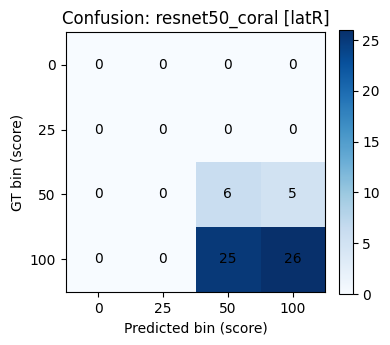

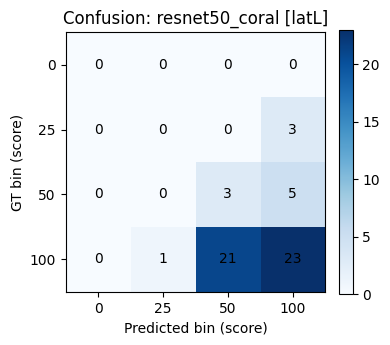

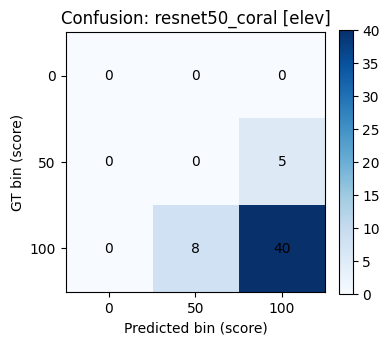

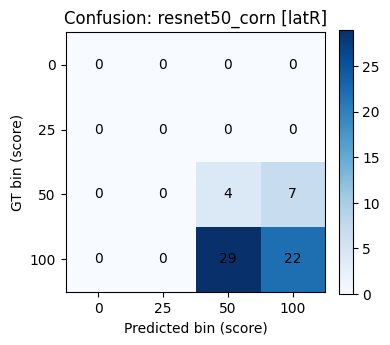

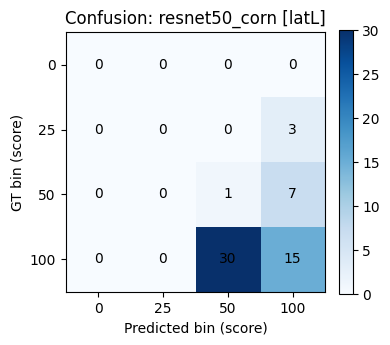

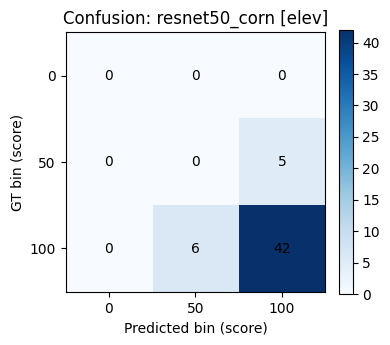

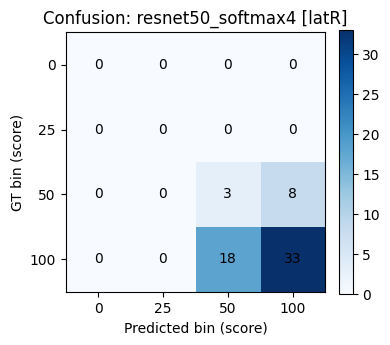

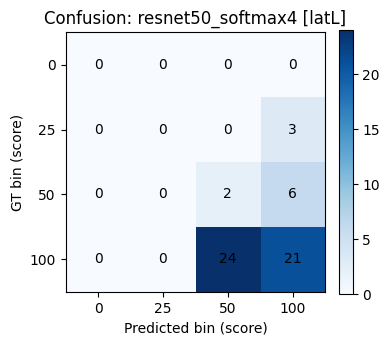

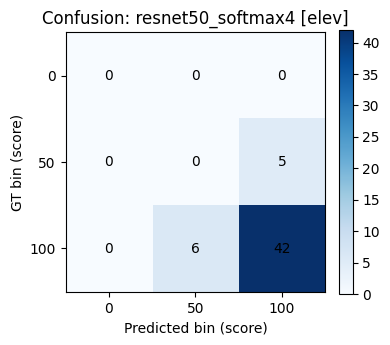

In [11]:
# Plot 1 — Confusion matrix (one per model per task)
# Make this cell robust to out-of-order execution.
if 'gt_bin' not in all_preds.columns or 'pred_bin' not in all_preds.columns:
    all_preds = all_preds.copy()
    all_preds['task'] = all_preds['task_id'].map(TASK_MAP)
    all_preds['anchors'] = all_preds['task'].map(TASK_ANCHORS)
    all_preds['pred_bin'] = all_preds.apply(
        lambda r: int(np.argmin(np.abs(np.asarray(r['anchors'], dtype=float) - float(r['pred_score'])))), axis=1
    )
    all_preds['gt_bin'] = all_preds.apply(
        lambda r: int(np.argmin(np.abs(np.asarray(r['anchors'], dtype=float) - float(r['true_score'])))), axis=1
    )

def confusion_from_bin_ids(df, n_bins):
    cm = np.zeros((n_bins, n_bins), dtype=int)
    for _, r in df.iterrows():
        y = int(r['gt_bin'])
        p = int(r['pred_bin'])
        if 0 <= y < n_bins and 0 <= p < n_bins:
            cm[y, p] += 1
    return cm

for model_name in sorted(all_preds['model'].unique()):
    model_df = all_preds[all_preds['model'] == model_name]
    for task_name in ['latR', 'latL', 'elev']:
        task_df = model_df[model_df['task'] == task_name]
        if task_df.empty:
            continue
        anchors = TASK_ANCHORS[task_name]
        tick_names = [str(int(x)) for x in anchors]
        cm = confusion_from_bin_ids(task_df, n_bins=len(anchors))

        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(cm, cmap='Blues')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha='center', va='center')
        ax.set_title(f'Confusion: {model_name} [{task_name}]')
        ax.set_xlabel('Predicted bin (score)')
        ax.set_ylabel('GT bin (score)')
        ax.set_xticks(range(len(tick_names)))
        ax.set_xticklabels(tick_names)
        ax.set_yticks(range(len(tick_names)))
        ax.set_yticklabels(tick_names)
        fig.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.show()


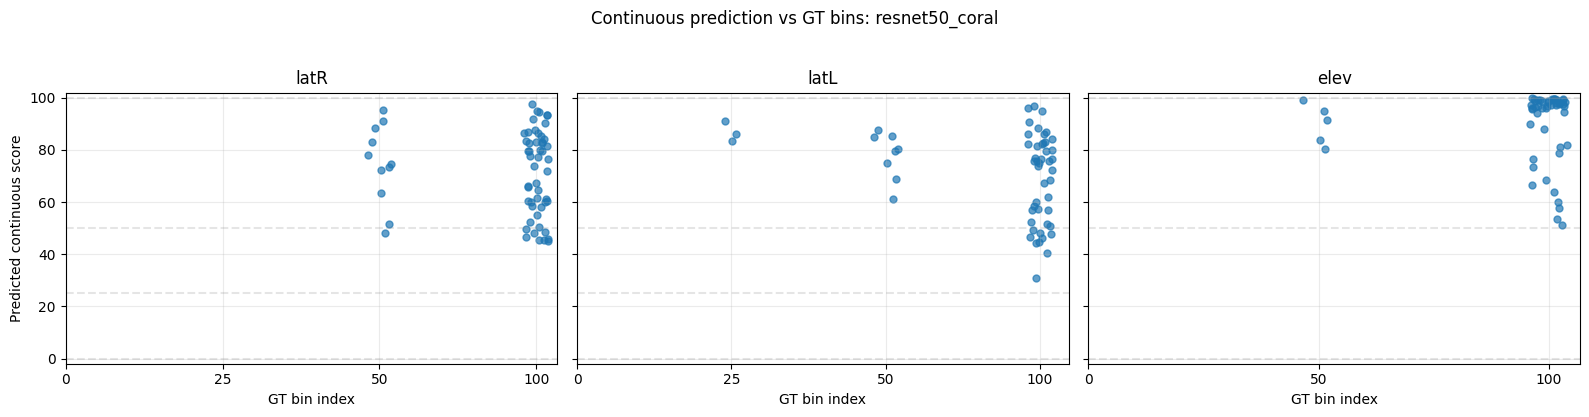

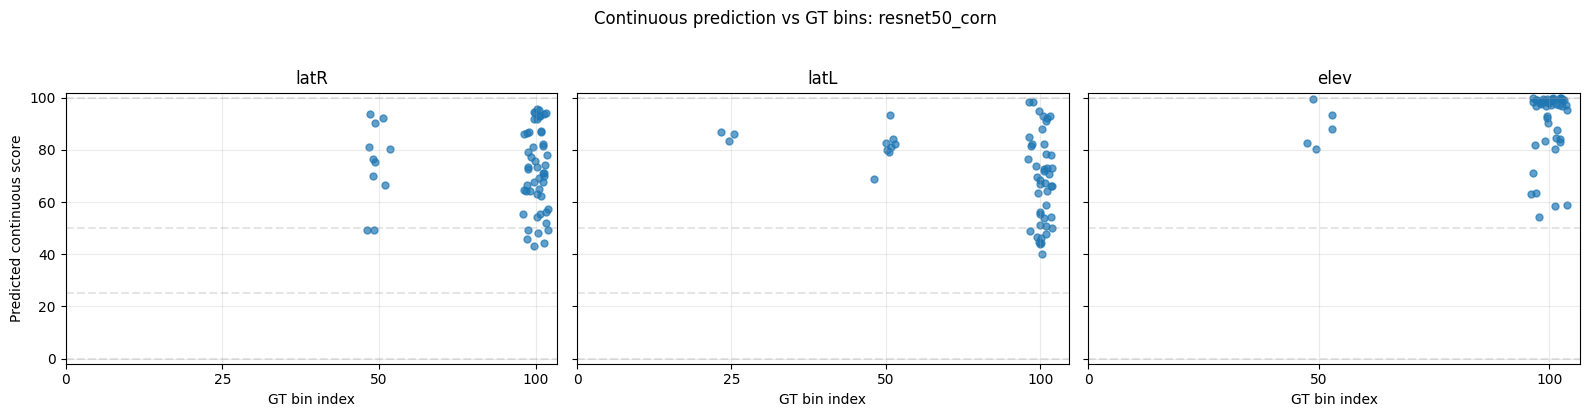

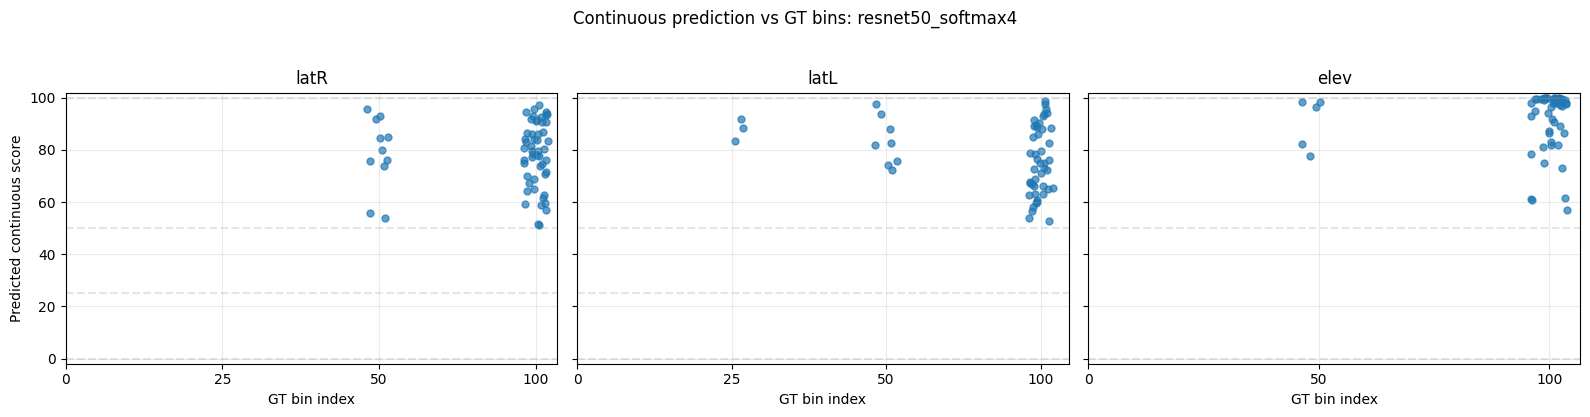

In [15]:
# Plot 2 — Predicted continuous vs GT discrete (scatter)
if 'gt_bin' not in all_preds.columns:
    all_preds = all_preds.copy()
    all_preds['task'] = all_preds['task_id'].map(TASK_MAP)
    all_preds['anchors'] = all_preds['task'].map(TASK_ANCHORS)
    all_preds['gt_bin'] = all_preds.apply(
        lambda r: int(np.argmin(np.abs(np.asarray(r['anchors'], dtype=float) - float(r['true_score'])))), axis=1
    )

for model_name in sorted(all_preds['model'].unique()):
    model_df = all_preds[all_preds['model'] == model_name]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

    for ax, task_name in zip(axes, ['latR', 'latL', 'elev']):
        task_df = model_df[model_df['task'] == task_name].copy()
        if task_df.empty:
            ax.set_title(f'{task_name}: no samples')
            ax.axis('off')
            continue

        anchors = TASK_ANCHORS[task_name]
        jitter = np.random.uniform(-0.08, 0.08, size=len(task_df))
        x = task_df['gt_bin'].values + jitter
        y = task_df['pred_score'].values
        ax.scatter(x, y, alpha=0.7, s=25)

        # Horizontal reference lines for valid bins
        for sc in anchors:
            ax.axhline(sc, color='gray', linestyle='--', alpha=0.2)

        ax.set_title(task_name)
        ax.set_xlabel('GT bin index')
        ax.set_xticks(range(len(anchors)))
        ax.set_xticklabels([str(int(a)) for a in anchors])
        ax.set_ylim(-2, 102)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel('Predicted continuous score')
    fig.suptitle(f'Continuous prediction vs GT bins: {model_name}', y=1.03)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


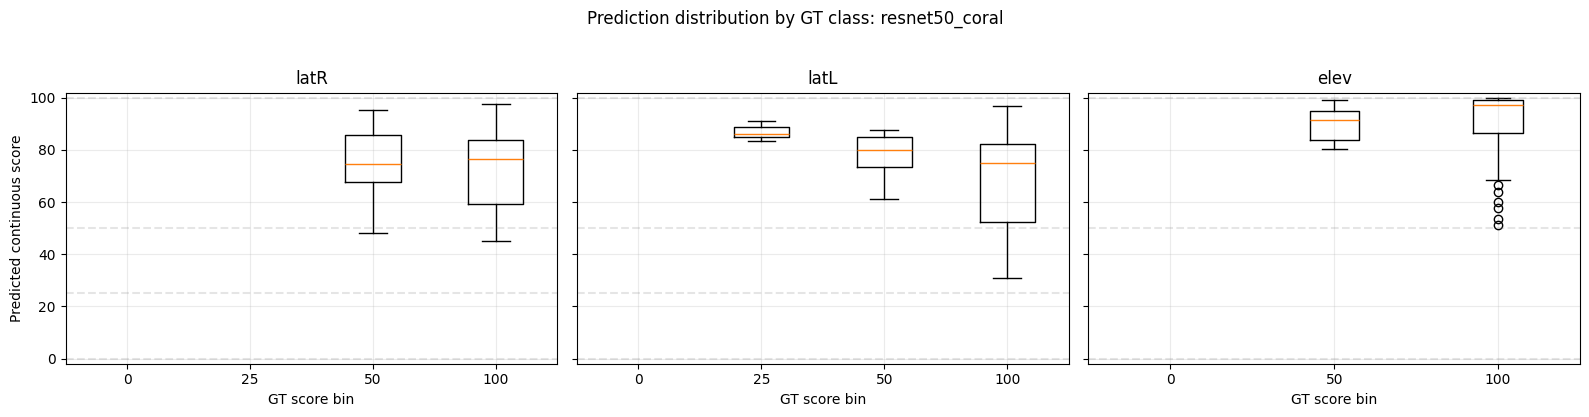

/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


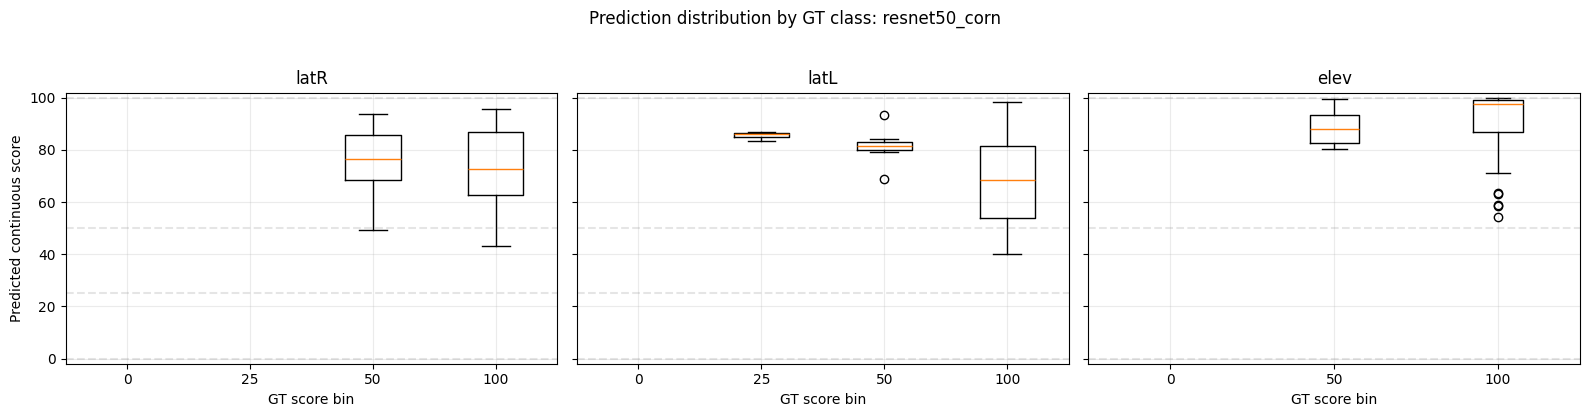

/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)
/tmp/ipykernel_2645312/2847471740.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


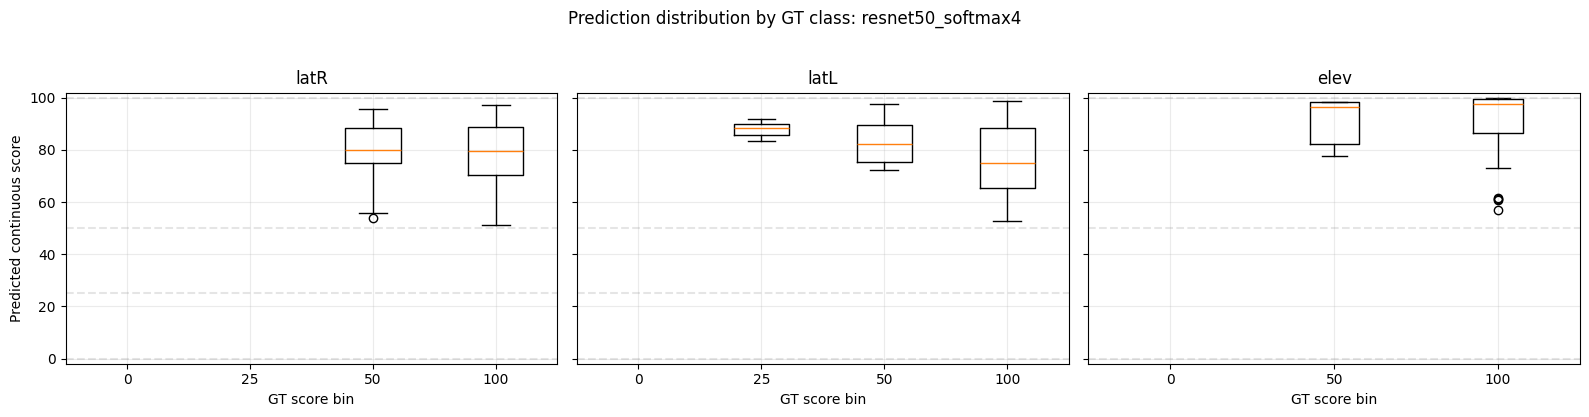

In [12]:
# Plot 3 — Box plot of continuous predictions per GT class
if 'gt_bin' not in all_preds.columns:
    all_preds = all_preds.copy()
    all_preds['task'] = all_preds['task_id'].map(TASK_MAP)
    all_preds['anchors'] = all_preds['task'].map(TASK_ANCHORS)
    all_preds['gt_bin'] = all_preds.apply(
        lambda r: int(np.argmin(np.abs(np.asarray(r['anchors'], dtype=float) - float(r['true_score'])))), axis=1
    )

for model_name in sorted(all_preds['model'].unique()):
    model_df = all_preds[all_preds['model'] == model_name]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

    for ax, task_name in zip(axes, ['latR', 'latL', 'elev']):
        task_df = model_df[model_df['task'] == task_name].copy()
        if task_df.empty:
            ax.set_title(f'{task_name}: no samples')
            ax.axis('off')
            continue

        anchors = TASK_ANCHORS[task_name]
        data = [task_df.loc[task_df['gt_bin'] == i, 'pred_score'].values for i in range(len(anchors))]
        labels = [str(int(a)) for a in anchors]

        ax.boxplot(data, labels=labels, showfliers=True)
        for sc in anchors:
            ax.axhline(sc, color='gray', linestyle='--', alpha=0.2)
        ax.set_title(task_name)
        ax.set_xlabel('GT score bin')
        ax.grid(alpha=0.25)

    axes[0].set_ylabel('Predicted continuous score')
    axes[0].set_ylim(-2, 102)
    fig.suptitle(f'Prediction distribution by GT class: {model_name}', y=1.03)
    plt.tight_layout()
    plt.show()


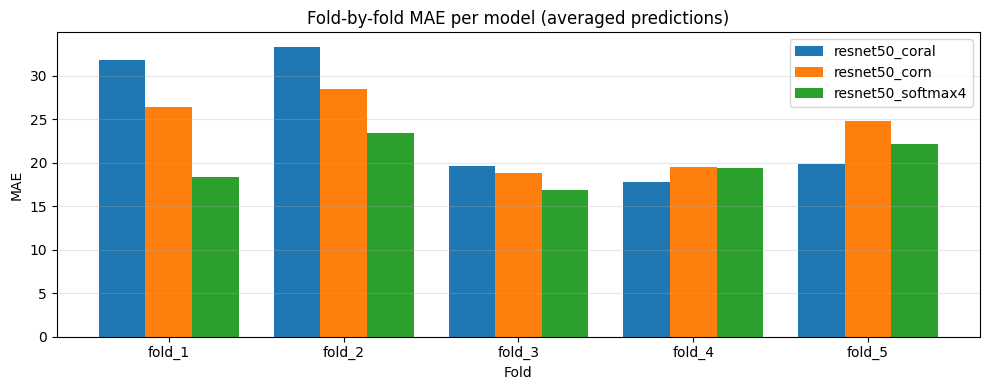

                model    fold     mae
0      resnet50_coral  fold_1  31.797
1      resnet50_coral  fold_2  33.331
2      resnet50_coral  fold_3  19.601
3      resnet50_coral  fold_4  17.830
4      resnet50_coral  fold_5  19.851
5       resnet50_corn  fold_1  26.448
6       resnet50_corn  fold_2  28.525
7       resnet50_corn  fold_3  18.869
8       resnet50_corn  fold_4  19.499
9       resnet50_corn  fold_5  24.751
10  resnet50_softmax4  fold_1  18.303
11  resnet50_softmax4  fold_2  23.416
12  resnet50_softmax4  fold_3  16.904
13  resnet50_softmax4  fold_4  19.418
14  resnet50_softmax4  fold_5  22.115


In [13]:
# Plot 4 — MAE per fold per model (side-by-side bars)
# If averaged predictions are loaded, this is MAE of averaged predictions.
fold_mae = (
    all_preds.assign(abs_err=(all_preds['pred_score'] - all_preds['true_score']).abs())
    .groupby(['model', 'fold'], as_index=False)
    .agg(mae=('abs_err', 'mean'))
)

if fold_mae.empty:
    raise RuntimeError('No fold-level predictions available for MAE plot')

models = sorted(fold_mae['model'].unique())
folds = sorted(fold_mae['fold'].unique())
x = np.arange(len(folds))
width = 0.8 / max(1, len(models))

fig, ax = plt.subplots(figsize=(10, 4))
for i, m in enumerate(models):
    vals = []
    for f in folds:
        r = fold_mae[(fold_mae['model'] == m) & (fold_mae['fold'] == f)]
        vals.append(float(r['mae'].iloc[0]) if len(r) else np.nan)
    ax.bar(x + (i - (len(models)-1)/2)*width, vals, width=width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('MAE')
ax.set_xlabel('Fold')
ax.set_title('Fold-by-fold MAE per model (averaged predictions)')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(fold_mae.sort_values(['model', 'fold']).round(3))


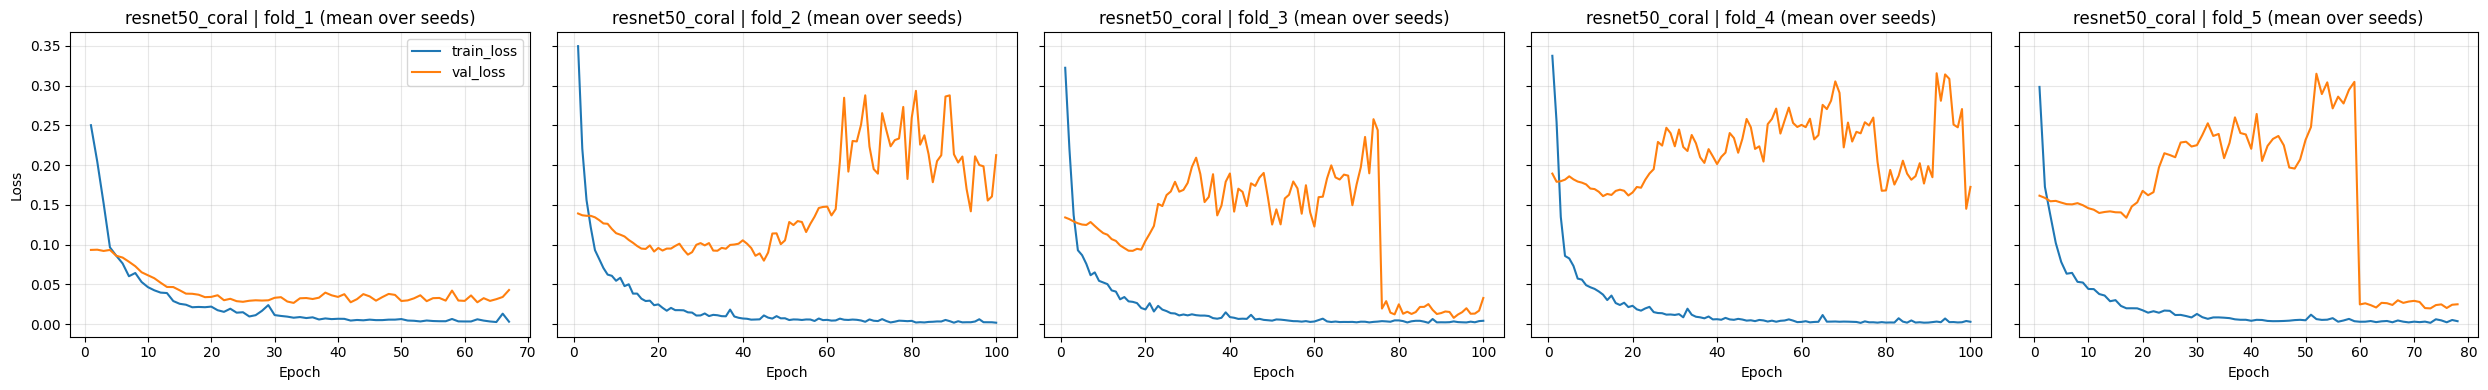

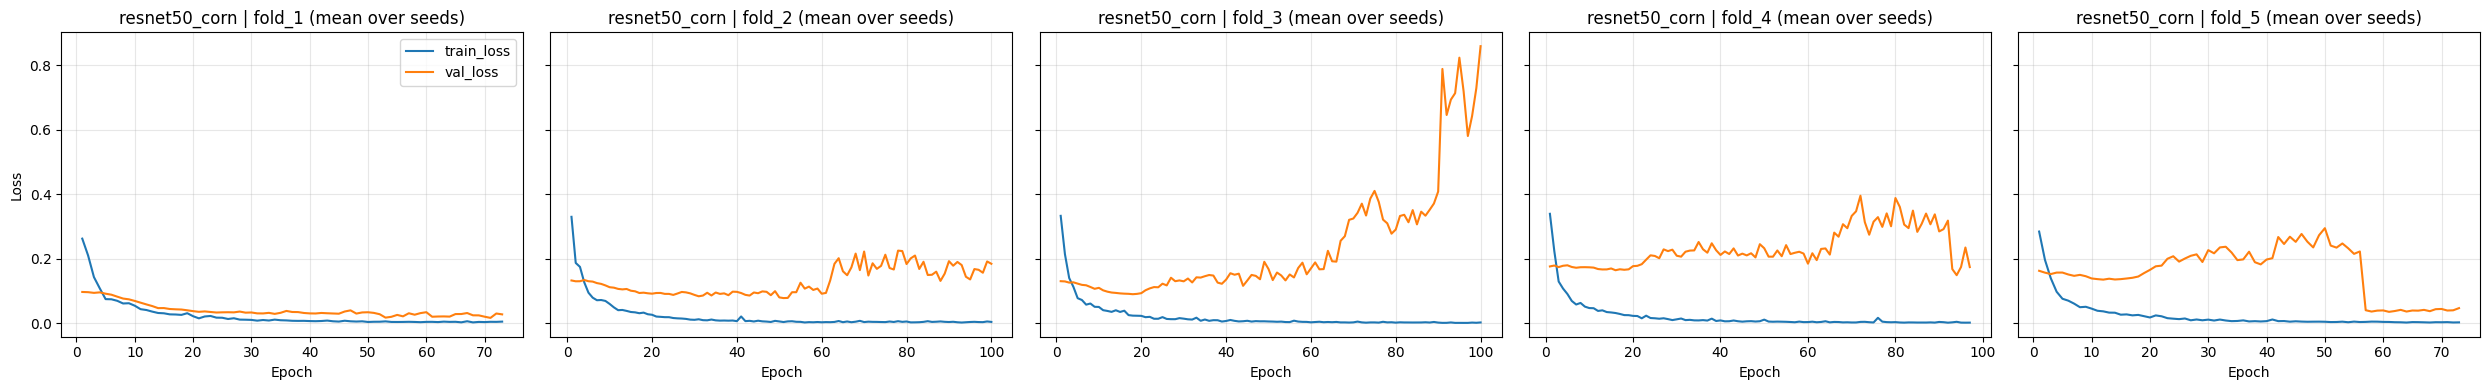

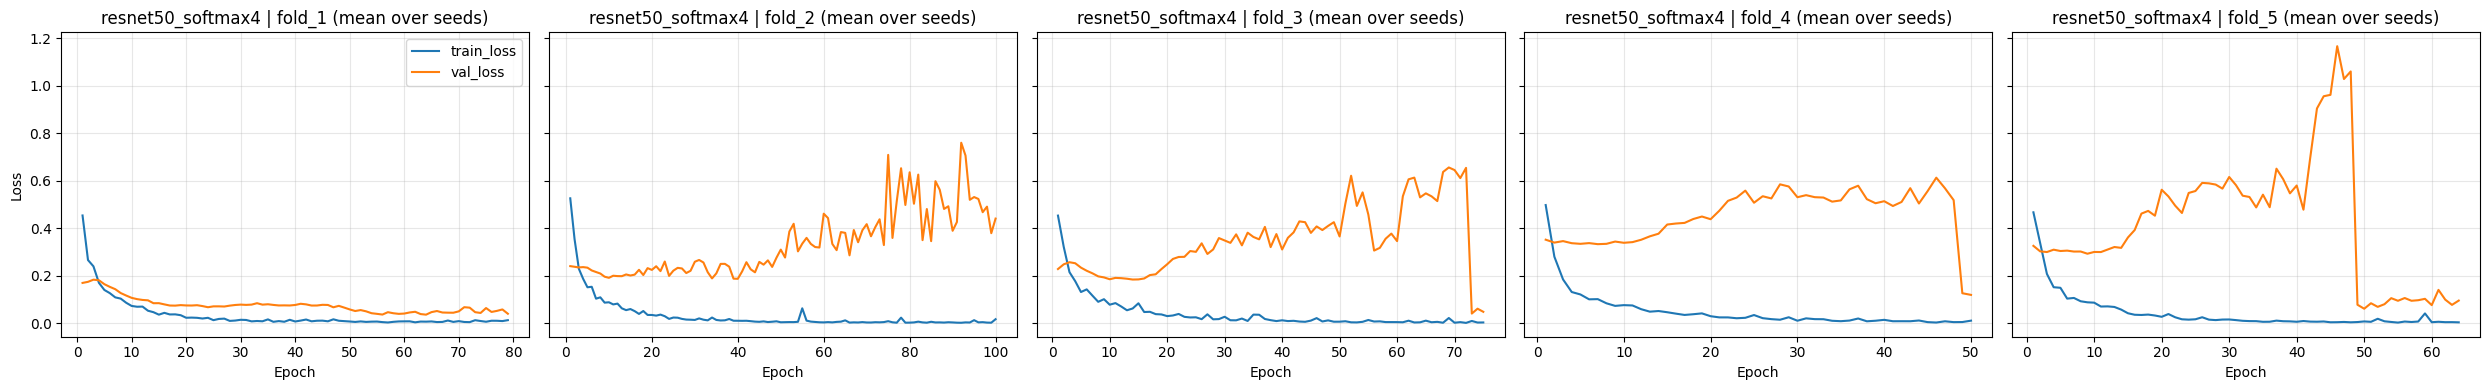

In [14]:
# Plot 5 — Learning curves (train loss vs val loss)
# For multi-seed runs, this shows mean curve across seeds for each fold.
if hist_df.empty:
    raise RuntimeError('No history.csv files found for learning curves')

for model_name in sorted(hist_df['model'].unique()):
    mdf = hist_df[hist_df['model'] == model_name].copy()
    folds = sorted(mdf['fold'].unique())
    n = len(folds)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, fold in zip(axes, folds):
        fdf = mdf[mdf['fold'] == fold].copy()
        if fdf.empty:
            ax.set_title(f'{model_name} | {fold} (no data)')
            continue
        mean_df = (
            fdf.groupby('epoch', as_index=False)
            .agg(train_loss=('train_loss', 'mean'), val_loss=('val_loss', 'mean'))
            .sort_values('epoch')
        )
        ax.plot(mean_df['epoch'], mean_df['train_loss'], label='train_loss')
        ax.plot(mean_df['epoch'], mean_df['val_loss'], label='val_loss')
        ax.set_title(f'{model_name} | {fold} (mean over seeds)')
        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Loss')
    axes[0].legend()
    plt.tight_layout()
    plt.show()
